**Провести анализ, найти закономерности и сделать вывод**

Каждая строчка наборов данных содержит следующие поля:

-***Survived*** — выжил данный пассажир или нет (0 для умерших, 1 для выживших)

-***Pclass*** — класс пассажира (1 — _высший_, 2 — _средний_, 3 — _низший_);

-***Name*** — имя;

-***Sex*** — пол;

-***Age*** — возраст;

-***SibSp*** — количество братьев, сестер, сводных братьев, сводных сестер, супругов на борту титаника;

-***Parch*** — количество родителей, детей (в том числе приемных) на борту титаника;

-***Ticket*** — номер билета;

-***Fare*** — плата за проезд;

-***Cabin*** — каюта;

-***Embarked*** — порт посадки (C — _Шербур_; Q — _Квинстаун_; S — _Саутгемптон_).

Файл: **train.csv**

In [113]:
import pandas as pd
import numpy as np
%matplotlib inline
import seaborn as sns
from matplotlib import pyplot as plt
pd.set_option("display.precision", 2)
from scipy.stats import mannwhitneyu 

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C


In [36]:
"На борту было {} мужчин и {} женщин.".format(sum(df['Sex'] == 'male'), 
                                            sum(df['Sex'] == 'female'))

'На борту было 577 мужчин и 314 женщин.'

In [28]:
d=df.groupby("Sex",as_index=False).agg({"PassengerId": "count"}).sort_values("PassengerId",ascending=False)\
    .rename(columns={"PassengerId":"count"})

<AxesSubplot: xlabel='Sex', ylabel='count'>

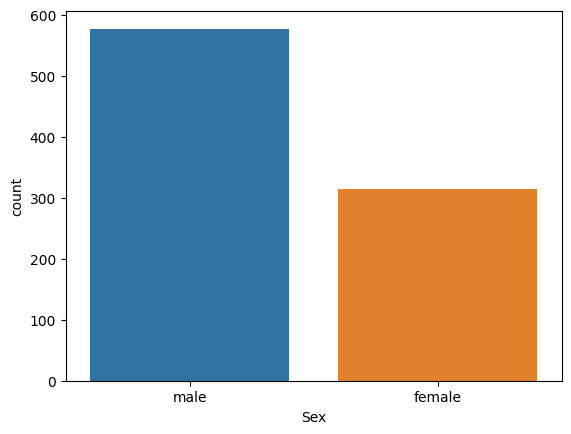

In [29]:
sns.barplot(data=d,x="Sex",y="count")

Колличество мужчин и женщин по классам

In [34]:
col_male_in_class = df.pivot_table(index=['Sex'], columns=['Pclass'], values='Name', aggfunc='count')

In [35]:
col_male_in_class.loc['female', [1, 2, 3]]

Pclass
1     94
2     76
3    144
Name: female, dtype: int64

In [37]:
col_male_in_class.loc['male', [1, 2, 3]]

Pclass
1    122
2    108
3    347
Name: male, dtype: int64

In [38]:
pd.crosstab(df['Pclass'], df['Sex'], margins=True)

Sex,female,male,All
Pclass,,,
1,94,122,216
2,76,108,184
3,144,347,491
All,314,577,891


***Расспределение полов по классам***


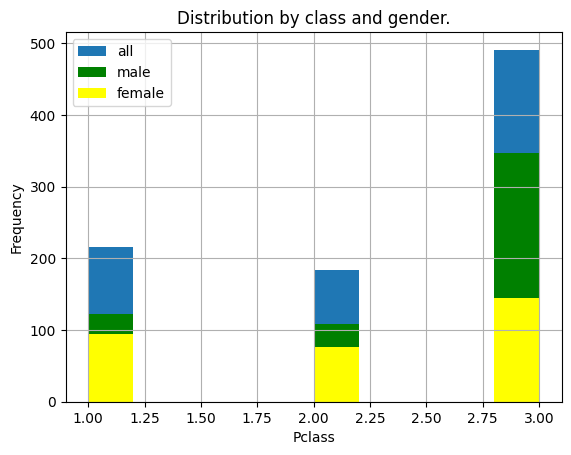

In [51]:
df['Pclass'].hist(label='all')
df[df['Sex'] == 'male']['Pclass'].hist(color="green", 
                                           label='male')
df[df['Sex'] == 'female']['Pclass'].hist(color="yellow", 
                                             label='female')
plt.title('Distribution by class and gender.')
plt.xlabel('Pclass')
plt.ylabel('Frequency')
plt.legend(loc='upper left')

***Доля выживших детей к взрослым***

In [52]:
young_survived = df[df['Age'] < 18]['Survived']
old_survived = df[df['Age'] >= 18]['Survived']

print("Доли выживших: \n\t среди молодых {}%, \n\t среди старых {}%.".format(
    round(100 * young_survived.mean(), 1), 
        round(100 * old_survived.mean(), 1)))

Доли выживших: 
	 среди молодых 54.0%, 
	 среди старых 38.1%.


<AxesSubplot: >

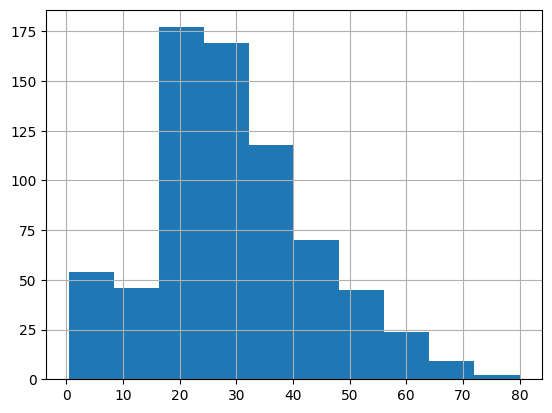

In [105]:
df.Age.hist()

Больший процент выживаемости наблюдаем у пассажиров до 18 лет. (Но не очень-то бльшой. Всё-таки жажда выжить оказывается сильнее благоразумия и сострадания)

***Выжившие и погибшие среди детей***

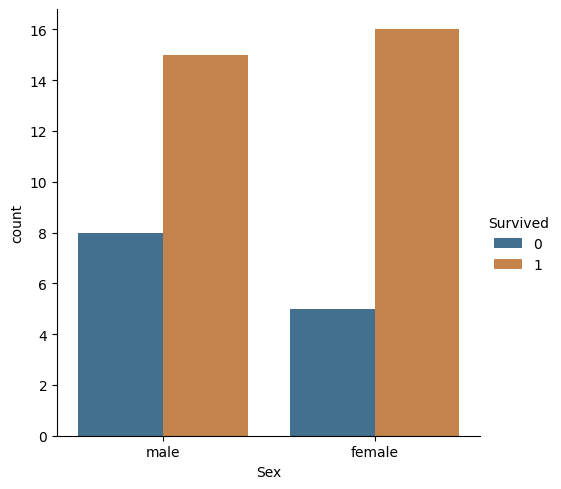

In [114]:
child= df[df.Age<6]
sns.catplot(data = child,hue = 'Survived', 
            x = 'Sex',kind='count', saturation=0.5)

***доли выживших мужчин / женщин***

In [53]:
male_survived = df[df['Sex'] == 'male']['Survived']
female_survived = df[df['Sex'] == 'female']['Survived']


print("Доли выживыших: \n\t среди женщин {}%, \n\t среди мужчин {}%".format(
    round(100 * female_survived.mean(), 1), round(100 * male_survived.mean(), 1)))

Доли выживыших: 
	 среди женщин 74.2%, 
	 среди мужчин 18.9%


Здесь прямо порадовалась за жертвенность мужчин. Хотя, возможно, команда корабля так сработала. Не смотрела "Титаник", не в курсе благодаря чему такие цифры.

***Добавим колонку с категорией возраста***

Из распределения, видно, что людей 30 лет погибло больше остальных

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '(0.419, 17.0]'),
  Text(1, 0, '(17.0, 21.714]'),
  Text(2, 0, '(21.714, 26.0]'),
  Text(3, 0, '(26.0, 30.0]'),
  Text(4, 0, '(30.0, 36.0]'),
  Text(5, 0, '(36.0, 45.5]'),
  Text(6, 0, '(45.5, 80.0]')])

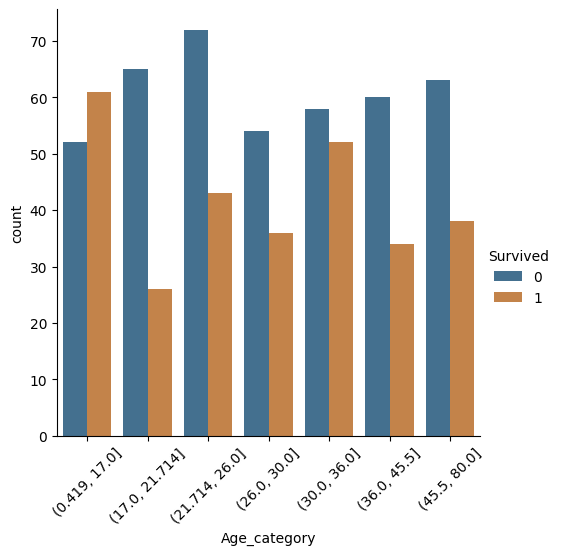

In [112]:
df['Age_category'] = pd.qcut(df.Age,7)
sns.catplot(data = df,hue = 'Survived', x = 'Age_category',
            kind='count', saturation=0.5) 
plt.xticks(rotation=45)

***Выжившие среди пассажиров пожилого возраста***

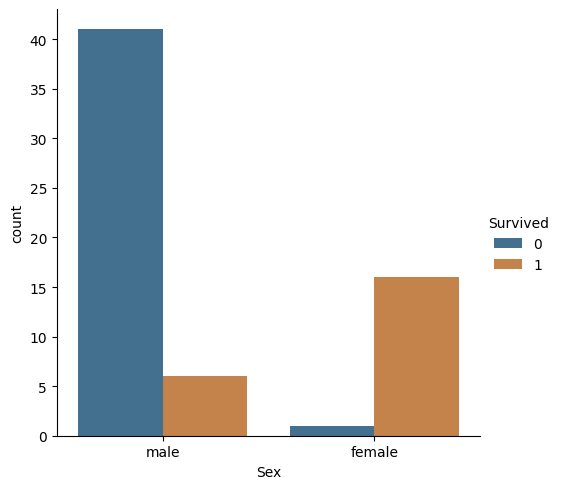

In [115]:
grand= df[df.Age>50]
sns.catplot(data = grand,hue = 'Survived', 
            x = 'Sex',kind='count', saturation=0.5)

In [111]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_cat
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,"(21.714, 26.0]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C,"(36.0, 45.5]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,"(21.714, 26.0]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S,"(30.0, 36.0]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,"(30.0, 36.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S,"(26.0, 30.0]"
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S,"(17.0, 21.714]"
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C,"(21.714, 26.0]"


***Графическое распределение стоимости билетов и возраста у спасенных и у погибших***

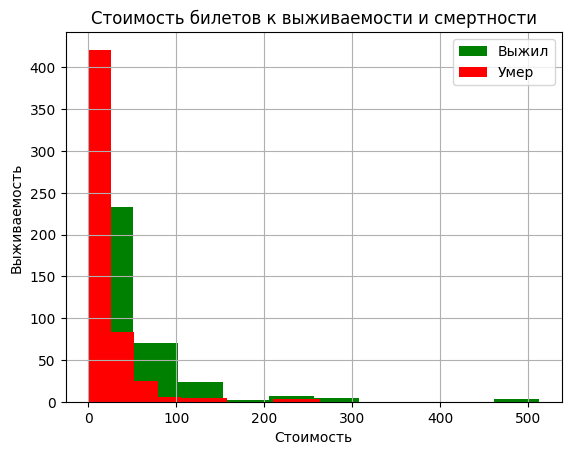

In [55]:
df[df['Survived'] == 1]['Fare'].hist(color="green", 
                                         label='Выжил')
df[df['Survived'] == 0]['Fare'].hist(color="red", 
                                         label='Умер')
plt.title('Стоимость билетов к выживаемости и смертности')
plt.xlabel('Стоимость')
plt.ylabel('Выживаемость')
plt.legend();

**Вывод**

Выживаемость у пассажиров к стоимости билетов:
Выше стоимость - больше выживаемость 

***Соотношение Выжившие/Возраст***

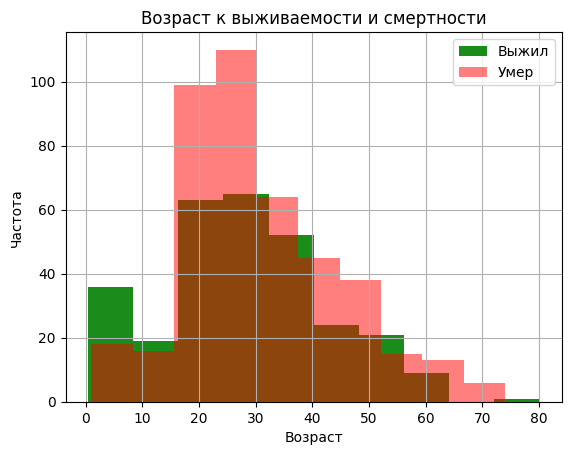

In [60]:
df[df['Survived'] == 1]['Age'].hist(color="green", 
                                         label='Выжил', alpha=.9)
df[df['Survived'] == 0]['Age'].hist(color="red", 
                                         label='Умер', alpha=.5)
plt.title('Возраст к выживаемости и смертности')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.legend()

Видно, что в среднем погибшие были старше. Но посчитаем детальнее:

In [66]:
df.groupby('Survived')['Age'].mean()

Survived
0    30.63
1    28.34
Name: Age, dtype: float64

Точно! Средний возраст погибших больше.

***Средний возраст мужчин / женщин в зависимости от класса обслуживания***

In [67]:
for cl in df['Pclass'].unique():
    for sex in df['Sex'].unique():
        print("Средний  возраст для {0} и класса {1}: {2}".format(sex, cl, 
            round(df[(df['Sex'] == sex)
                         & (df['Pclass'] == cl)]['Age'].mean(),2)))

Средний  возраст для male и класса 3: 26.51
Средний  возраст для female и класса 3: 21.75
Средний  возраст для male и класса 1: 41.28
Средний  возраст для female и класса 1: 34.61
Средний  возраст для male и класса 2: 30.74
Средний  возраст для female и класса 2: 28.72


***Посчитаем сумму счастливых билетов***

_счастливый билет эт тот, в котором сумма первых трёх цифр равняется сумме последних трёх цифр_

In [69]:
c=0
l=[]
for k,v in df["Ticket"].items():
    if len(v)==6 and v.isdigit():
        a=int(v)
        sum_left = 0
        sum_right = 0
        for i in range(6):
            if i<3:
                sum_right += a // 10**i % 10
            else:
                sum_left  += a // 10**i % 10 
        if sum_left == sum_right:
            c+=1
            l.append(k)
f"Всего счастливых билетов {c}"

'Всего счастливых билетов 27'

In [72]:
import csv
c_v=0
with open("train.csv") as file:
    rows = csv.reader(file)                               # создаем reader объект
    for row in rows:
        if row[1]=="1" and int(row[0]) in l:
            c_v+=1
f"Выживших среди счастливых билетов {c_v}"

'Выживших среди счастливых билетов 9'

In [73]:
df.Ticket.count()

891

In [75]:
df.query("Survived==1")["PassengerId"].count()

342

**Среди счастливых билетов соотношение выживших 1 к 3.**

**Среди не счастливых - 1 к 2.59.**

**Всё же, данные дают пологать нам, что доля везение может присутствовать.**


***Братьев и сестер на борту***


In [78]:
df.SibSp.unique()

array([1, 0, 3, 4, 2, 5, 8], dtype=int64)

In [79]:
df.SibSp.describe()

count    891.00
mean       0.52
std        1.10
min        0.00
25%        0.00
50%        0.00
75%        1.00
max        8.00
Name: SibSp, dtype: float64

***Родителей- детей на борту***

In [80]:
df.Parch.unique()

array([0, 1, 2, 5, 3, 4, 6], dtype=int64)

In [81]:
df.Parch.describe()

count    891.00
mean       0.38
std        0.81
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        6.00
Name: Parch, dtype: float64

Иногда семьи насчитывали до 9 человек. 

Большинство пассажиров путешествовавали в одиночку. 

Мужчин почти в два раза больше женщин.

***Была ли разница для мужчин / женщин в тарифах билетов.***

In [88]:
men = df[df.Sex == "male"] 


In [89]:
women = df[df.Sex == "female"]

In [95]:
stat, p = mannwhitneyu(men.Age, women.Age)
print('Критерий значимости = %.3f' % (p))
alpha = 0.1
if p > alpha:
  print('Возраст не отличался')
else:
  print('Действительно разный возраст, мужчины ', 
        men.Age.mean(),', женщины ', women.Age.mean())

Критерий значимости = nan
Действительно разный возраст, мужчины  30.72664459161148 , женщины  27.915708812260537


In [92]:
stat, p = mannwhitneyu(men.Fare, women.Fare)
print('Критерий значимости = %.3f' % (p))
alpha = 0.1
if p > alpha:
  print('Возраст не отличался')
else: 
  print('Действительно разный тариф, мужчины ',
        men.Fare.mean(),', женщины ', women.Fare.mean())

Критерий значимости = 0.000
Действительно разный тариф, мужчины  25.523893414211443 , женщины  44.47981783439491


Женщинам путешествовать обходилось дороже. 


***Еще одна визуализация выживание по классам и полу***

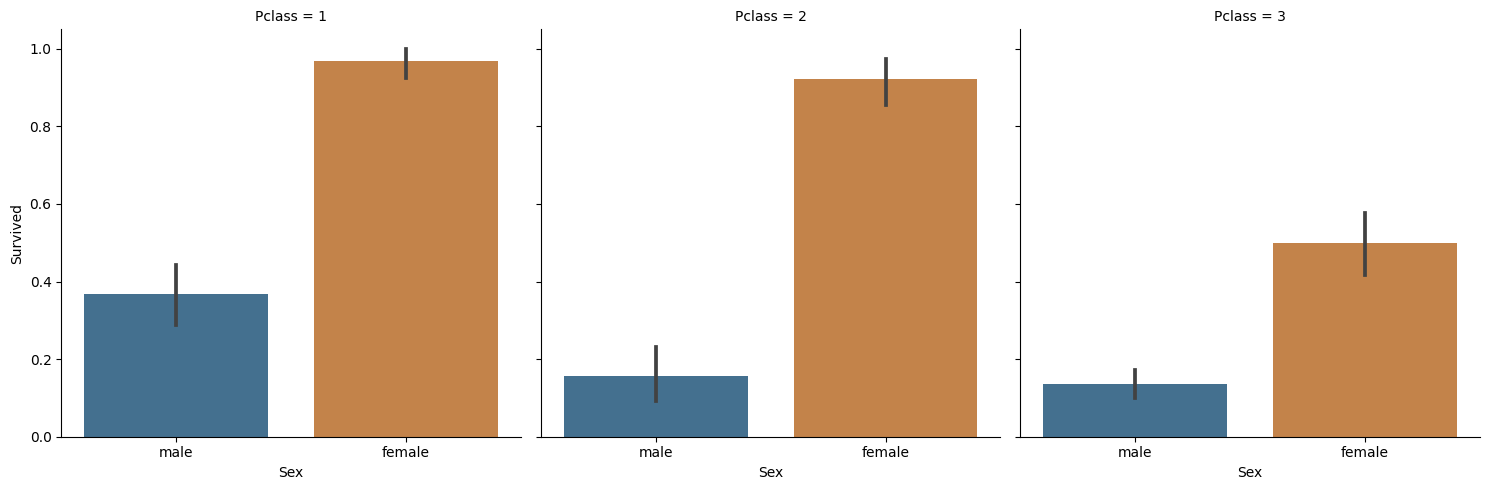

In [101]:
sns.catplot(data = df,y='Survived',x='Sex',col='Pclass',
            kind='bar', saturation=0.5)

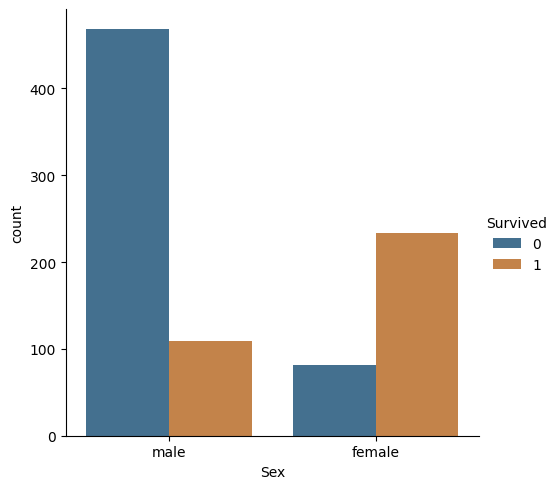

In [102]:
sns.catplot(data = df,hue = 'Survived', x = 'Sex',
            kind='count', saturation=0.5)

Во всех классах женщины спаслись больше мужчин, это говорит о героизме мужчин на борту, так как мы ранее узнали, что их было значительно больше, а также наблюдаем, что пассажиров первого класса спаслось больше

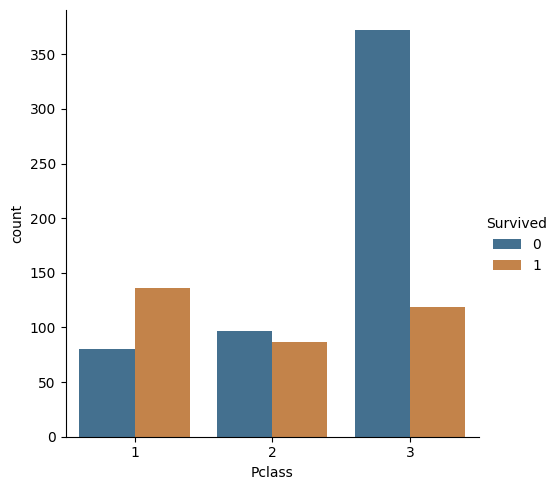

In [104]:
sns.catplot(data = df,hue = 'Survived', x = 'Pclass',
            kind='count', saturation=0.5)

Больше погибших среди 3-его класса.

***Проверим как наличие семьи на борту повлияло на выживаемость***

In [117]:
df = df.drop('Age_cat', axis=1)
df['family'] = df['Parch'] + df['SibSp']

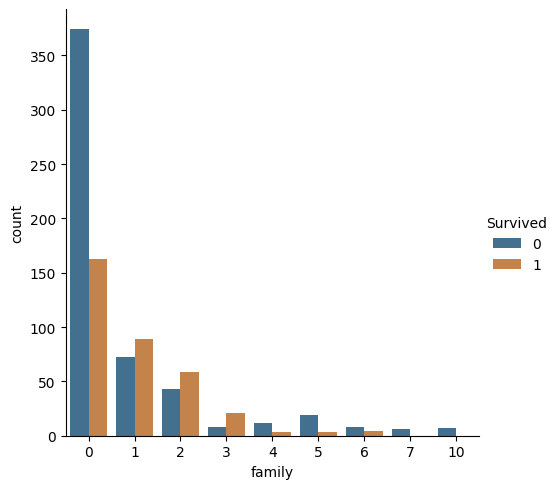

In [118]:
sns.catplot(data = df,hue = 'Survived', x = 'family',
            kind='count', saturation=0.5)

***Чем меньше семья- тем больше шансов выжить.***